In [1]:
import math
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

pd.set_option("display.max_columns", 160)
pd.set_option("display.width", 180)

# Model setup and parameterization

## HealthPark Medical Center nexus

In [21]:
power_chain_nodes = [
    "PP_1_failed",
    "SUB_1_failed",
    "SUB_2_failed",
    "SUB_3_failed",
    "SUB_4_failed",
    "SUB_5_failed",
]

power_chain_edges = [
    {
        "parent": parent,
        "child": child,
        "relationship": "Sequential power delivery chain from plant through substations to HealthPark Medical Center",
    }
    for parent, child in zip(power_chain_nodes[:-1], power_chain_nodes[1:])
]

dependency_edges = pd.DataFrame(
    # Power chain edges
    power_chain_edges
    + [
        {"parent": "SUB_5_failed", "child": "Generator_activated", "relationship": "Tier 1 generator activates when final upstream substation service is unavailable"},
        {"parent": "Generator_activated", "child": "ElectricalDistribution_failed", "relationship": "Generator buffers power outage for 6.3 days"},

        # Water supply edges
        {"parent": "WTP_1_failed", "child": "WaterDistribution_failed", "relationship": "Shared water provider without backup"},

        # Communication edges
        {"parent": "LEE_DARK_FIBER_failed", "child": "Communication_Tier1_failed", "relationship": "Tier 1 primary communications"},
        {"parent": "LUMEN_MPLS_failed", "child": "Communication_Tier1_failed", "relationship": "Tier 1 backup communications"},
        {"parent": "COMCAST_ENS_failed", "child": "Communication_Tier1_failed", "relationship": "Tier 1 backup communications"},
        {"parent": "LUMEN_MPLS_failed", "child": "Communication_Tier2_failed", "relationship": "Tier 2 communications"},
        {"parent": "COMCAST_ENS_failed", "child": "Communication_Tier2_failed", "relationship": "Tier 2 communications"},
        {"parent": "LUMEN_MPLS_failed", "child": "Communication_Tier3_failed", "relationship": "Tier 3 primary communications"},
        {"parent": "COMCAST_BUSINESS_failed", "child": "Communication_Tier3_failed", "relationship": "Tier 3 backup communications"},
        {"parent": "TMOBILE_5G_failed", "child": "Communication_Tier3_failed", "relationship": "Tier 3 backup communications"},

        # Transportation edges
        {"parent": "roads_bridges_closure", "child": "Operations_capability_reduced", "relationship": "Reduced operations capability due to transportation disruptions for staff and supplies"},

        # Internal utility dependencies
        {"parent": "ElectricalDistribution_failed", "child": "WaterDistribution_failed", "relationship": "Internal utility dependency between electrical and water distribution"},

        # Tier functionality dependencies
        {"parent": "ElectricalDistribution_failed", "child": "Tier1_failed", "relationship": "Tier 1 functionality dependency"},
        {"parent": "WaterDistribution_failed", "child": "Tier1_failed", "relationship": "Tier 1 functionality dependency"},
        {"parent": "Communication_Tier1_failed", "child": "Tier1_failed", "relationship": "Tier 1 functionality dependency"},
        {"parent": "Operations_capability_reduced", "child": "Tier1_failed", "relationship": "Tier 1 functionality dependency"},

        {"parent": "ElectricalDistribution_failed", "child": "Tier2_failed", "relationship": "Tier 2 functionality dependency"},
        {"parent": "WaterDistribution_failed", "child": "Tier2_failed", "relationship": "Tier 2 functionality dependency"},
        {"parent": "Communication_Tier2_failed", "child": "Tier2_failed", "relationship": "Tier 2 functionality dependency"},
        {"parent": "Operations_capability_reduced", "child": "Tier2_failed", "relationship": "Tier 2 functionality dependency"},

        {"parent": "ElectricalDistribution_failed", "child": "Tier3_failed", "relationship": "Tier 3 functionality dependency"},
        {"parent": "WaterDistribution_failed", "child": "Tier3_failed", "relationship": "Tier 3 functionality dependency"},
        {"parent": "Communication_Tier3_failed", "child": "Tier3_failed", "relationship": "Tier 3 functionality dependency"},
        {"parent": "Operations_capability_reduced", "child": "Tier3_failed", "relationship": "Tier 3 functionality dependency"}
    ]
)

G = nx.DiGraph()
G.add_edges_from(dependency_edges[["parent", "child"]].itertuples(index=False, name=None))

dependency_edges

,parent,child,relationship
0,PP_1_failed,SUB_1_failed,Sequential power delivery chain from plant thr...
1,SUB_1_failed,SUB_2_failed,Sequential power delivery chain from plant thr...
2,SUB_2_failed,SUB_3_failed,Sequential power delivery chain from plant thr...
3,SUB_3_failed,SUB_4_failed,Sequential power delivery chain from plant thr...
4,SUB_4_failed,SUB_5_failed,Sequential power delivery chain from plant thr...
5,SUB_5_failed,Generator_activated,Tier 1 generator activates when final upstream...
6,Generator_activated,ElectricalDistribution_failed,Generator buffers power outage for 6.3 days
7,WTP_1_failed,WaterDistribution_failed,Shared water provider without backup
8,LEE_DARK_FIBER_failed,Communication_Tier1_failed,Tier 1 primary communications
9,LUMEN_MPLS_failed,Communication_Tier1_failed,Tier 1 backup communications


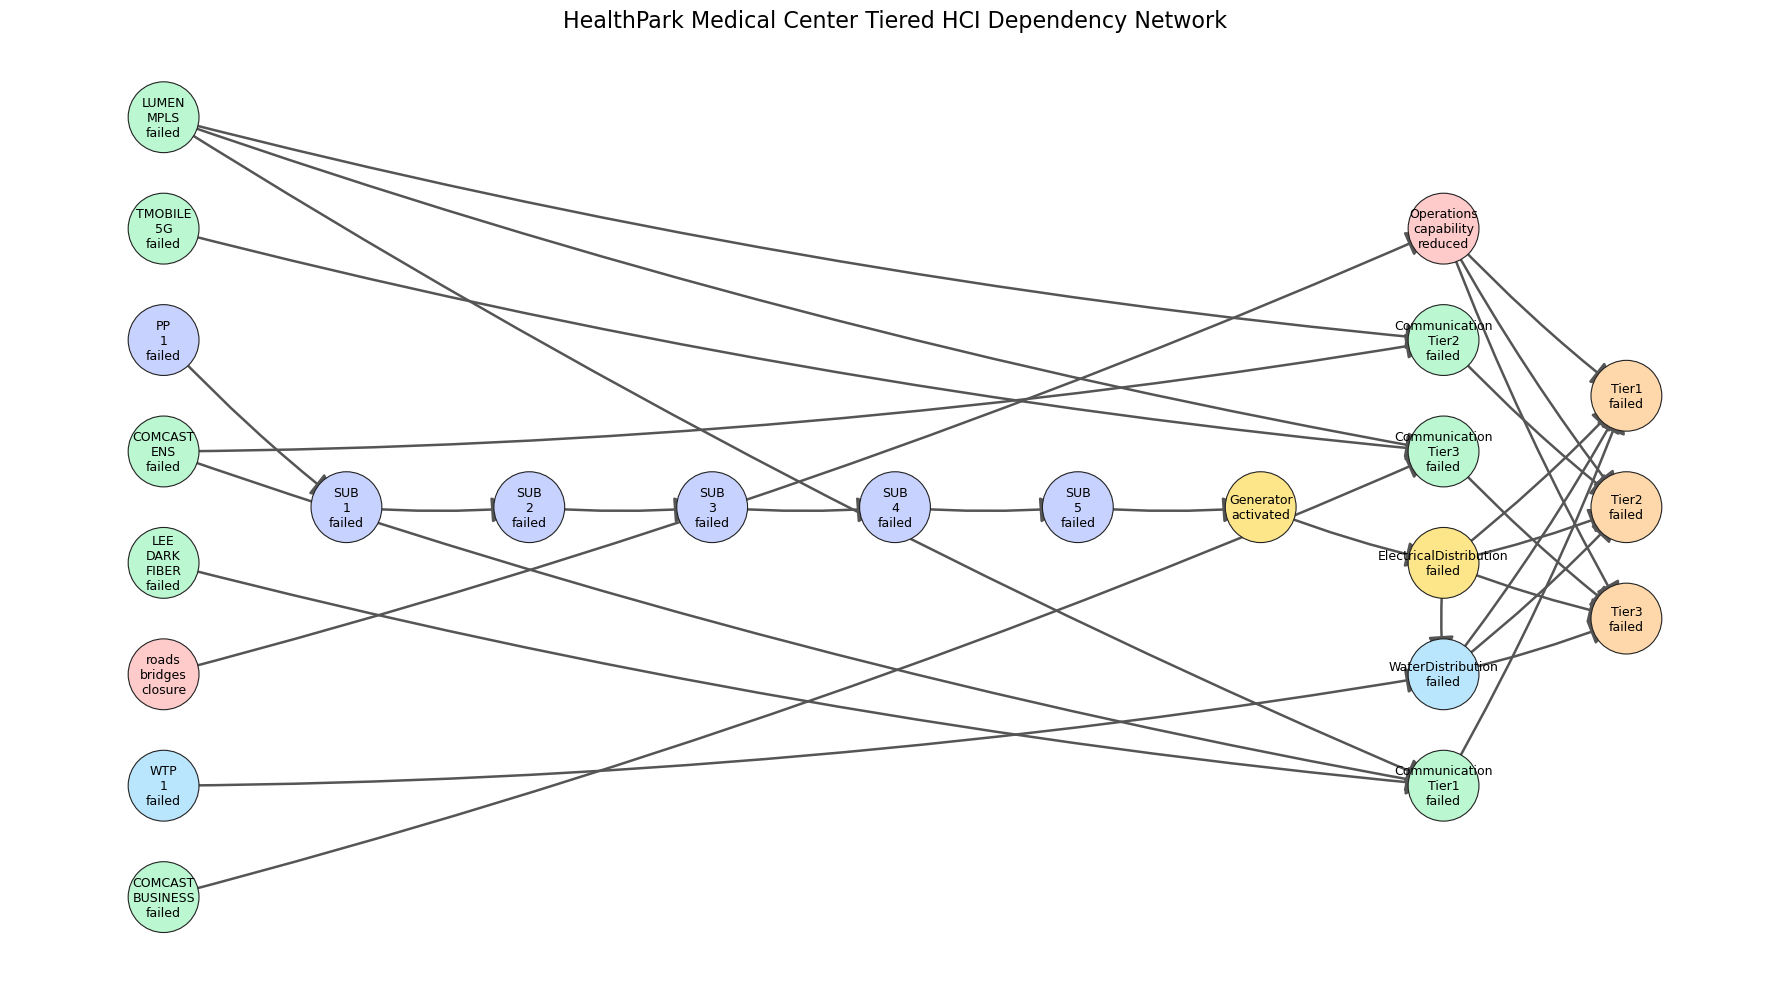

In [22]:
G = nx.DiGraph()
G.add_edges_from(dependency_edges[["parent", "child"]].itertuples(index=False, name=None))

layer_map = {
    "PP_1_failed": 0,
    "SUB_1_failed": 1,
    "SUB_2_failed": 2,
    "SUB_3_failed": 3,
    "SUB_4_failed": 4,
    "SUB_5_failed": 5,

    "WTP_1_failed": 0,
    "LEE_DARK_FIBER_failed": 0,
    "LUMEN_MPLS_failed": 0,
    "COMCAST_ENS_failed": 0,
    "COMCAST_BUSINESS_failed": 0,
    "TMOBILE_5G_failed": 0,
    "roads_bridges_closure": 0,

    "Generator_activated": 6,

    "ElectricalDistribution_failed": 7,

    "WaterDistribution_failed": 7,
    "Communication_Tier1_failed": 7,
    "Communication_Tier2_failed": 7,
    "Communication_Tier3_failed": 7,
    "Operations_capability_reduced": 7,

    "Tier1_failed": 8,
    "Tier2_failed": 8,
    "Tier3_failed": 8,
}

nx.set_node_attributes(G, layer_map, "layer")
pos = nx.multipartite_layout(G, subset_key="layer", align="vertical", scale=2.2)

node_colors = []
for node in G.nodes:
    if node.startswith("PP") or node.startswith("SUB"):
        node_colors.append("#c7d2fe")  # power chain
    elif "Generator" in node or "Electrical" in node:
        node_colors.append("#fde68a")  # electrical service
    elif "Water" in node or node.startswith("WTP"):
        node_colors.append("#bae6fd")  # water
    elif "Communication" in node or "FIBER" in node or "MPLS" in node or "COMCAST" in node or "TMOBILE" in node:
        node_colors.append("#bbf7d0")  # communications
    elif "roads" in node or "Operations" in node:
        node_colors.append("#fecaca")  # transportation / operations
    elif node.startswith("Tier"):
        node_colors.append("#fed7aa")  # hospital tiers
    else:
        node_colors.append("#e5e7eb")

plt.figure(figsize=(18, 10))
nx.draw_networkx_edges(
    G,
    pos,
    arrows=True,
    arrowstyle="-|>",
    arrowsize=40,
    width=1.8,
    edge_color="#555555",
    connectionstyle="arc3,rad=0.04",
)
nx.draw_networkx_nodes(
    G,
    pos,
    node_color=node_colors,
    node_size=2600,
    edgecolors="#222222",
    linewidths=0.8,
)
nx.draw_networkx_labels(
    G,
    pos,
    labels={node: node.replace("_", "\n") for node in G.nodes},
    font_size=9,
)

plt.title("HealthPark Medical Center Tiered HCI Dependency Network", fontsize=16)
plt.axis("off")
plt.tight_layout()
plt.show()

## Rountine failure probability

In [125]:
# ---------------------------------------------------------------------
# Baseline routine failure probabilities
# ---------------------------------------------------------------------
# These are point-in-time probabilities estimated as failed hours / observed hours.
# Replace failed_hours with local logs when available.

routine_failure_logs = pd.DataFrame([
    # Power chain
    {"variable": "PP_1_failed", "observed_hours": 8760, "failed_hours": 1, "routine_p_failed": 1 / 8760, "source": "placeholder; rare non-hurricane plant/bulk supply outage"},
    {"variable": "SUB_1_failed", "observed_hours": 8760, "failed_hours": 6, "routine_p_failed": 6 / 8760, "source": "placeholder; substation/feeder outage"},
    {"variable": "SUB_2_failed", "observed_hours": 8760, "failed_hours": 6, "routine_p_failed": 6 / 8760, "source": "placeholder; substation/feeder outage"},
    {"variable": "SUB_3_failed", "observed_hours": 8760, "failed_hours": 6, "routine_p_failed": 6 / 8760, "source": "placeholder; substation/feeder outage"},
    {"variable": "SUB_4_failed", "observed_hours": 8760, "failed_hours": 6, "routine_p_failed": 6 / 8760, "source": "placeholder; substation/feeder outage"},
    {"variable": "SUB_5_failed", "observed_hours": 8760, "failed_hours": 6, "routine_p_failed": 6 / 8760, "source": "placeholder; final substation/feeder outage"},

    # Water
    {"variable": "WTP_1_failed", "observed_hours": 8760, "failed_hours": 2, "routine_p_failed": 2 / 8760, "source": "placeholder; water treatment operational interruption"},
    # {"variable": "WaterDistribution_failed", "observed_hours": 8760, "failed_hours": 1, "routine_p_failed": 1 / 8760, "source": "placeholder; distribution pressure/quality interruption"},

    # Communications
    {"variable": "LEE_DARK_FIBER_failed", "observed_hours": 8760, "failed_hours": 6, "routine_p_failed": 6 / 8760, "source": "placeholder; dark fiber interruption"},
    {"variable": "LUMEN_MPLS_failed", "observed_hours": 8760, "failed_hours": 12, "routine_p_failed": 12 / 8760, "source": "placeholder; MPLS provider interruption"},
    {"variable": "COMCAST_ENS_failed", "observed_hours": 8760, "failed_hours": 12, "routine_p_failed": 12 / 8760, "source": "placeholder; ENS provider interruption"},
    {"variable": "COMCAST_BUSINESS_failed", "observed_hours": 8760, "failed_hours": 16, "routine_p_failed": 16 / 8760, "source": "placeholder; business internet interruption"},
    {"variable": "TMOBILE_5G_failed", "observed_hours": 8760, "failed_hours": 10, "routine_p_failed": 10 / 8760, "source": "placeholder; wireless service interruption"},

    # Transportation
    {"variable": "roads_bridges_closure", "observed_hours": 8760, "failed_hours": 0, "routine_p_failed": 0 / 8760, "source": "placeholder; routine road/bridge closure"}
])

routine_probability_lookup = dict(zip(
    routine_failure_logs["variable"],
    routine_failure_logs["routine_p_failed"],
))

def p_routine(variable):
    return float(routine_probability_lookup.get(variable, 0.0))

routine_failure_logs

,variable,observed_hours,failed_hours,routine_p_failed,source
0,PP_1_failed,8760,1,0.000114,placeholder; rare non-hurricane plant/bulk sup...
1,SUB_1_failed,8760,6,0.000685,placeholder; substation/feeder outage
2,SUB_2_failed,8760,6,0.000685,placeholder; substation/feeder outage
3,SUB_3_failed,8760,6,0.000685,placeholder; substation/feeder outage
4,SUB_4_failed,8760,6,0.000685,placeholder; substation/feeder outage
5,SUB_5_failed,8760,6,0.000685,placeholder; final substation/feeder outage
6,WTP_1_failed,8760,2,0.000228,placeholder; water treatment operational inter...
7,LEE_DARK_FIBER_failed,8760,6,0.000685,placeholder; dark fiber interruption
8,LUMEN_MPLS_failed,8760,12,0.001370,placeholder; MPLS provider interruption
9,COMCAST_ENS_failed,8760,12,0.001370,placeholder; ENS provider interruption


## Fragility curves under flood depth

For HealthPark Medical Center:

- First floor elevation is 10 ft above sea level
- Generator plant finished floor elevation is 12 ft above sea level
- 8-10 ft surge may cause first-floor water intrusion
- 11-15 ft surge likely causes 1-4 ft water on first floor
- Above 15 ft likely causes more than 3 ft water on first floor

,node_category,x_zero_ft,x_low_ft,p_low,x_high_ft,p_high,basis,x50_ft,k,fit_error,x50_m
0,PowerPlant,8.0,10.0,0.05,17.0,0.80,Generic planning prior for large power asset e...,14.488978,0.564329,7.394622e-08,4.416240
1,Substation,8.0,9.0,0.05,15.0,0.85,Electrical equipment is flood-sensitive; FEMA/...,12.270541,0.658918,3.206831e-07,3.740061
2,WaterTreatmentPlant,8.0,10.0,0.05,16.0,0.75,"Generic planning prior for pumps, controls, tr...",14.172345,0.617535,4.632864e-08,4.319731
3,Communication,7.0,8.0,0.05,15.0,0.75,"Generic planning prior for telecom cabinets, h...",12.166333,0.434269,1.881451e-07,3.708298
4,Transportation,6.0,8.0,0.10,13.0,0.85,Road and bridge closures become increasingly l...,10.585170,0.735772,1.177920e-07,3.226360
5,Generator,10.0,12.0,0.20,15.0,0.90,HealthPark note: generator/switchgear may beco...,13.082164,1.161423,3.723443e-08,3.987444
6,Hospital,8.0,9.0,0.10,15.0,0.90,HealthPark note: possible intrusion near 9-10 ...,11.104208,0.605711,8.406363e-07,3.384563


node_category,Communication,Generator,Hospital,PowerPlant,Substation,Transportation,WaterTreatmentPlant
storm_surge_ft,,,,,,,
0,0.000,0.000,0.000,0.000,0.000,0.000,0.000
5,0.000,0.000,0.000,0.000,0.000,0.000,0.000
6,0.000,0.000,0.000,0.000,0.000,0.000,0.000
7,0.000,0.000,0.000,0.000,0.000,0.035,0.000
8,0.050,0.000,0.000,0.000,0.000,0.100,0.000
9,0.117,0.000,0.099,0.019,0.050,0.211,0.018
10,0.204,0.000,0.238,0.050,0.134,0.373,0.050
11,0.310,0.056,0.406,0.100,0.260,0.561,0.104
12,0.427,0.200,0.576,0.176,0.423,0.730,0.190


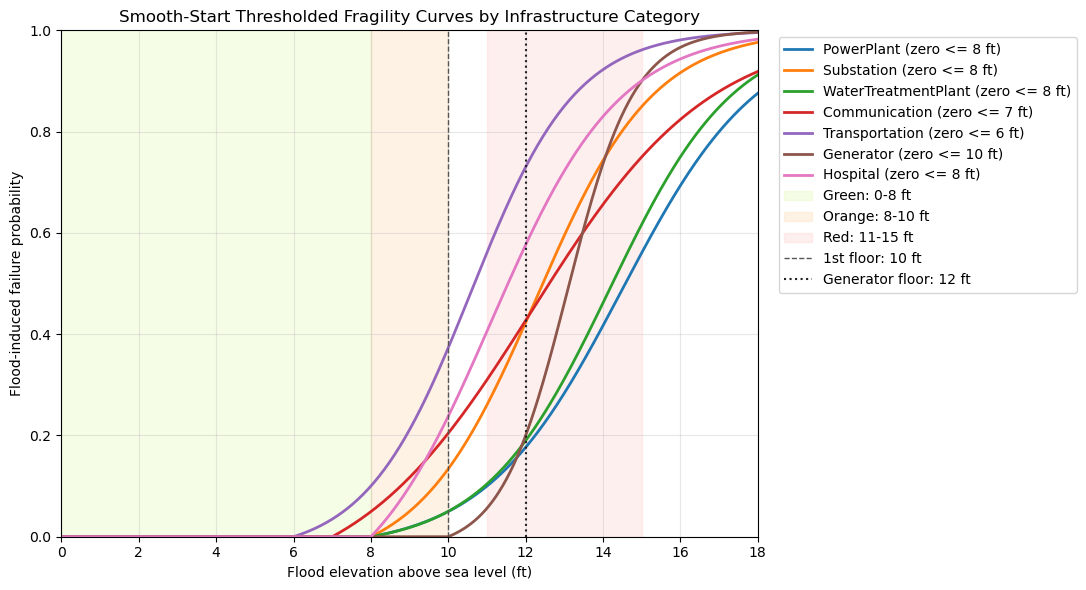

In [167]:
# ---------------------------------------------------------------------
# Smooth-start thresholded fragility curves
# ---------------------------------------------------------------------
# HealthPark Medical Center reference elevations:
# - First floor elevation: 10 ft above sea level
# - Generator plant finished floor elevation: 12 ft above sea level
# - 8-10 ft surge may cause first-floor water intrusion
# - 11-15 ft surge likely causes 1-4 ft water on first floor
# - Above 15 ft likely causes more than 3 ft water on first floor
#
# Categories:
# PowerPlant, Substation, WaterTreatmentPlant, Communication,
# Transportation, Generator, Hospital
# ---------------------------------------------------------------------

FT_TO_M = 0.3048

HOSPITAL_FIRST_FLOOR_ELEVATION_FT = 10.0
GENERATOR_PLANT_FLOOR_ELEVATION_FT = 12.0


def raw_sigmoid(x, x50, k):
    return 1.0 / (1.0 + math.exp(-k * (x - x50)))


def shifted_sigmoid_probability(x, x_zero, x50, k):
    """
    Smooth-start shifted sigmoid.

    P(x) = 0 for x <= x_zero.
    For x > x_zero, the sigmoid is shifted/rescaled so that P(x_zero) = 0.
    """
    if x <= x_zero:
        return 0.0

    raw = raw_sigmoid(x, x50, k)
    raw_zero = raw_sigmoid(x_zero, x50, k)

    return (raw - raw_zero) / (1.0 - raw_zero)


def sigmoid_fragility(surge_ft, x_zero_ft, x50_ft, k):
    return shifted_sigmoid_probability(
        x=surge_ft,
        x_zero=x_zero_ft,
        x50=x50_ft,
        k=k,
    )


def sigmoid_params_from_anchors(x_zero, x_low, p_low, x_high, p_high):
    """
    Fit x50 and k so the smooth-start sigmoid approximately satisfies:

    P(x_zero) = 0
    P(x_low) = p_low
    P(x_high) = p_high

    Grid search is used because the shifted/rescaled sigmoid has no simple
    closed-form two-anchor solution.
    """
    best_x50 = None
    best_k = None
    best_error = np.inf

    x50_grid = np.linspace(x_low, x_high, 500)
    k_grid = np.linspace(0.05, 3.0, 500)

    for x50_candidate in x50_grid:
        for k_candidate in k_grid:
            p_low_hat = shifted_sigmoid_probability(
                x=x_low,
                x_zero=x_zero,
                x50=x50_candidate,
                k=k_candidate,
            )
            p_high_hat = shifted_sigmoid_probability(
                x=x_high,
                x_zero=x_zero,
                x50=x50_candidate,
                k=k_candidate,
            )

            error = (p_low_hat - p_low) ** 2 + (p_high_hat - p_high) ** 2

            if error < best_error:
                best_error = error
                best_x50 = x50_candidate
                best_k = k_candidate

    return best_x50, best_k, best_error


def combine_independent_probabilities(*probabilities):
    survival = 1.0
    for p in probabilities:
        survival *= 1.0 - float(p)
    return 1.0 - survival


fragility_anchor_parameters = pd.DataFrame([
    {
        "node_category": "PowerPlant",
        "x_zero_ft": 8.0,
        "x_low_ft": 10.0,
        "p_low": 0.05,
        "x_high_ft": 17.0,
        "p_high": 0.80,
        "basis": "Generic planning prior for large power asset exposure under major coastal flooding.",
    },
    {
        "node_category": "Substation",
        "x_zero_ft": 8.0,
        "x_low_ft": 9.0,
        "p_low": 0.05,
        "x_high_ft": 15.0,
        "p_high": 0.85,
        "basis": "Electrical equipment is flood-sensitive; FEMA/ASCE guidance emphasizes elevating electrical utilities above design flood elevations.",
    },
    {
        "node_category": "WaterTreatmentPlant",
        "x_zero_ft": 8.0,
        "x_low_ft": 10.0,
        "p_low": 0.05,
        "x_high_ft": 16.0,
        "p_high": 0.75,
        "basis": "Generic planning prior for pumps, controls, treatment processes, and site access under major flood exposure.",
    },
    {
        "node_category": "Communication",
        "x_zero_ft": 7.0,
        "x_low_ft": 8.0,
        "p_low": 0.05,
        "x_high_ft": 15.0,
        "p_high": 0.75,
        "basis": "Generic planning prior for telecom cabinets, hubs, backhaul, and local backup power under flood exposure.",
    },
    {
        "node_category": "Transportation",
        "x_zero_ft": 6.0,
        "x_low_ft": 8.0,
        "p_low": 0.10,
        "x_high_ft": 13.0,
        "p_high": 0.85,
        "basis": "Road and bridge closures become increasingly likely as flood elevation approaches major surge levels; roadway flooding can restrict staff and supply access.",
    },
    {
        "node_category": "Generator",
        "x_zero_ft": 10.0,
        "x_low_ft": 12.0,
        "p_low": 0.20,
        "x_high_ft": 15.0,
        "p_high": 0.90,
        "basis": "HealthPark note: generator/switchgear may become inoperable at 12-15 ft storm surge.",
    },
    {
        "node_category": "Hospital",
        "x_zero_ft": 8.0,
        "x_low_ft": 9.0,
        "p_low": 0.10,
        "x_high_ft": 15.0,
        "p_high": 0.90,
        "basis": "HealthPark note: possible intrusion near 9-10 ft; likely 1-4 ft first-floor water at 11-15 ft.",
    },
])

fragility_parameters = fragility_anchor_parameters.copy()

sigmoid_params = fragility_parameters.apply(
    lambda row: sigmoid_params_from_anchors(
        x_zero=row["x_zero_ft"],
        x_low=row["x_low_ft"],
        p_low=row["p_low"],
        x_high=row["x_high_ft"],
        p_high=row["p_high"],
    ),
    axis=1,
)

fragility_parameters["x50_ft"] = [params[0] for params in sigmoid_params]
fragility_parameters["k"] = [params[1] for params in sigmoid_params]
fragility_parameters["fit_error"] = [params[2] for params in sigmoid_params]
fragility_parameters["x50_m"] = fragility_parameters["x50_ft"] * FT_TO_M


node_category_lookup = {
    "PP_1_failed": "PowerPlant",

    "SUB_1_failed": "Substation",
    "SUB_2_failed": "Substation",
    "SUB_3_failed": "Substation",
    "SUB_4_failed": "Substation",
    "SUB_5_failed": "Substation",

    "WTP_1_failed": "WaterTreatmentPlant",

    "LEE_DARK_FIBER_failed": "Communication",
    "LUMEN_MPLS_failed": "Communication",
    "COMCAST_ENS_failed": "Communication",
    "COMCAST_BUSINESS_failed": "Communication",
    "TMOBILE_5G_failed": "Communication",

    "roads_bridges_closure": "Transportation",

    "ElectricalDistribution_failed": "Generator",

    "Tier1_failed": "Hospital",
    "Tier2_failed": "Hospital",
    "Tier3_failed": "Hospital",
}


def p_flood_failure_by_category(node_category, storm_surge_ft):
    row = fragility_parameters.loc[
        fragility_parameters["node_category"] == node_category
    ].iloc[0]

    return sigmoid_fragility(
        surge_ft=storm_surge_ft,
        x_zero_ft=row["x_zero_ft"],
        x50_ft=row["x50_ft"],
        k=row["k"],
    )


def p_flood_failure(variable, storm_surge_ft):
    node_category = node_category_lookup[variable]
    return p_flood_failure_by_category(node_category, storm_surge_ft)


def p_total_failure(variable, storm_surge_ft):
    p_flood = p_flood_failure(variable, storm_surge_ft)
    p_base = p_routine(variable)
    return combine_independent_probabilities(p_flood, p_base)


calibration_surge_levels_ft = [0, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 18]

surge_fragility_calibration_table = pd.DataFrame([
    {
        "node_category": row["node_category"],
        "x_zero_ft": row["x_zero_ft"],
        "storm_surge_ft": surge_ft,
        "p_flood_failure": sigmoid_fragility(
            surge_ft=surge_ft,
            x_zero_ft=row["x_zero_ft"],
            x50_ft=row["x50_ft"],
            k=row["k"],
        ),
    }
    for _, row in fragility_parameters.iterrows()
    for surge_ft in calibration_surge_levels_ft
])

display(fragility_parameters)

display(
    surge_fragility_calibration_table.pivot(
        index="storm_surge_ft",
        columns="node_category",
        values="p_flood_failure",
    ).round(3)
)


surge_grid_ft = np.linspace(0, 18, 400)

plt.figure(figsize=(11, 6))

for _, row in fragility_parameters.iterrows():
    probs = [
        sigmoid_fragility(
            surge_ft=s,
            x_zero_ft=row["x_zero_ft"],
            x50_ft=row["x50_ft"],
            k=row["k"],
        )
        for s in surge_grid_ft
    ]

    plt.plot(
        surge_grid_ft,
        probs,
        linewidth=2,
        label=f"{row['node_category']} (zero <= {row['x_zero_ft']:.0f} ft)",
    )

plt.axvspan(0, 8, color="#d9f99d", alpha=0.25, label="Green: 0-8 ft")
plt.axvspan(8, 10, color="#fed7aa", alpha=0.30, label="Orange: 8-10 ft")
plt.axvspan(11, 15, color="#fecaca", alpha=0.30, label="Red: 11-15 ft")
plt.axvline(10, color="#555555", linestyle="--", linewidth=1, label="1st floor: 10 ft")
plt.axvline(12, color="#222222", linestyle=":", linewidth=1.5, label="Generator floor: 12 ft")

plt.xlabel("Flood elevation above sea level (ft)")
plt.ylabel("Flood-induced failure probability")
plt.title("Smooth-Start Thresholded Fragility Curves by Infrastructure Category")
plt.ylim(0, 1)
plt.xlim(0, 18)
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Uncertainty range

In [132]:
# ---------------------------------------------------------------------
# Uncertainty ranges
# ---------------------------------------------------------------------
# Each category has uncertain low/high anchor points:
# P(failure at x_low_ft) = p_low
# P(failure at x_high_ft) = p_high
#
# These ranges are intentionally broad because local calibration is missing.

fragility_uncertainty_ranges = {
    "PowerPlant": {
        "x_low_ft": (9.0, 12.0),
        "p_low": (0.02, 0.10),
        "x_high_ft": (15.0, 18.0),
        "p_high": (0.60, 0.90),
    },
    "Substation": {
        "x_low_ft": (8.0, 11.0),
        "p_low": (0.03, 0.15),
        "x_high_ft": (13.0, 16.0),
        "p_high": (0.70, 0.95),
    },
    "WaterTreatmentPlant": {
        "x_low_ft": (9.0, 12.0),
        "p_low": (0.02, 0.12),
        "x_high_ft": (14.0, 17.0),
        "p_high": (0.60, 0.90),
    },
    "Communication": {
        "x_low_ft": (7.0, 10.0),
        "p_low": (0.03, 0.15),
        "x_high_ft": (13.0, 16.0),
        "p_high": (0.60, 0.90),
    },
    "Transportation": {
        "x_low_ft": (7.0, 9.0),
        "p_low": (0.05, 0.20),
        "x_high_ft": (12.0, 14.0),
        "p_high": (0.70, 0.95),
    },
    "Generator": {
        "x_low_ft": (11.5, 12.5),
        "p_low": (0.10, 0.35),
        "x_high_ft": (14.0, 15.5),
        "p_high": (0.75, 0.98),
    },
    "Hospital": {
        "x_low_ft": (8.5, 10.5),
        "p_low": (0.05, 0.20),
        "x_high_ft": (14.0, 16.0),
        "p_high": (0.75, 0.98),
    },
}

In [133]:
def sample_fragility_parameters(rng):
    rows = []

    for category, ranges in fragility_uncertainty_ranges.items():
        x_low = rng.uniform(*ranges["x_low_ft"])
        p_low = rng.uniform(*ranges["p_low"])
        x_high = rng.uniform(*ranges["x_high_ft"])
        p_high = rng.uniform(*ranges["p_high"])

        # Ensure anchors are ordered correctly.
        if x_high <= x_low:
            x_high = x_low + 1.0

        if p_high <= p_low:
            p_high = min(0.99, p_low + 0.20)

        x50, k = sigmoid_params_from_anchors(x_low, p_low, x_high, p_high)

        rows.append({
            "node_category": category,
            "x_low_ft": x_low,
            "p_low": p_low,
            "x_high_ft": x_high,
            "p_high": p_high,
            "x50_ft": x50,
            "k": k,
        })

    return pd.DataFrame(rows)

In [134]:
def p_flood_failure_with_params(variable, storm_surge_ft, sampled_fragility_parameters):
    category = node_category_lookup[variable]
    row = sampled_fragility_parameters.loc[
        sampled_fragility_parameters["node_category"] == category
    ].iloc[0]

    return sigmoid_fragility(
        surge_ft=storm_surge_ft,
        x50_ft=row["x50_ft"],
        k=row["k"],
    )

def p_total_failure_with_params(variable, storm_surge_ft, sampled_fragility_parameters):
    p_flood = p_flood_failure_with_params(
        variable,
        storm_surge_ft,
        sampled_fragility_parameters,
    )
    p_base = p_routine(variable)
    return combine_independent_probabilities(p_flood, p_base)

In [135]:
# ---------------------------------------------------------------------
# Category-level fragility uncertainty bands
# ---------------------------------------------------------------------

def run_category_fragility_uncertainty_test(
    surge_levels_ft=np.linspace(0, 18, 361),
    n_samples=2000,
    seed=20260727,
):
    rng = np.random.default_rng(seed)
    records = []

    for sample_id in range(n_samples):
        sampled_params = sample_fragility_parameters(rng)

        for _, row in sampled_params.iterrows():
            category = row["node_category"]

            for surge_ft in surge_levels_ft:
                records.append({
                    "sample_id": sample_id,
                    "node_category": category,
                    "storm_surge_ft": surge_ft,
                    "p_flood_failure": sigmoid_fragility(
                        surge_ft=surge_ft,
                        x50_ft=row["x50_ft"],
                        k=row["k"],
                    ),
                })

    return pd.DataFrame(records)


category_uncertainty_results = run_category_fragility_uncertainty_test(
    surge_levels_ft=np.linspace(0, 18, 361),
    n_samples=2000,
    seed=20260727,
)

category_uncertainty_summary = (
    category_uncertainty_results
    .groupby(["storm_surge_ft", "node_category"])["p_flood_failure"]
    .quantile([0.05, 0.50, 0.95])
    .unstack()
    .reset_index()
    .rename(columns={0.05: "p05", 0.50: "p50", 0.95: "p95"})
)

category_uncertainty_summary.head()

,storm_surge_ft,node_category,p05,p50,p95
0,0.0,Communication,7.132689e-06,5.569916e-04,0.007470
1,0.0,Generator,3.635334e-12,1.987889e-07,0.000097
2,0.0,Hospital,1.708207e-06,1.408364e-04,0.002258
3,0.0,PowerPlant,1.808529e-07,4.686837e-05,0.001185
4,0.0,Substation,2.256156e-08,3.989729e-05,0.001558


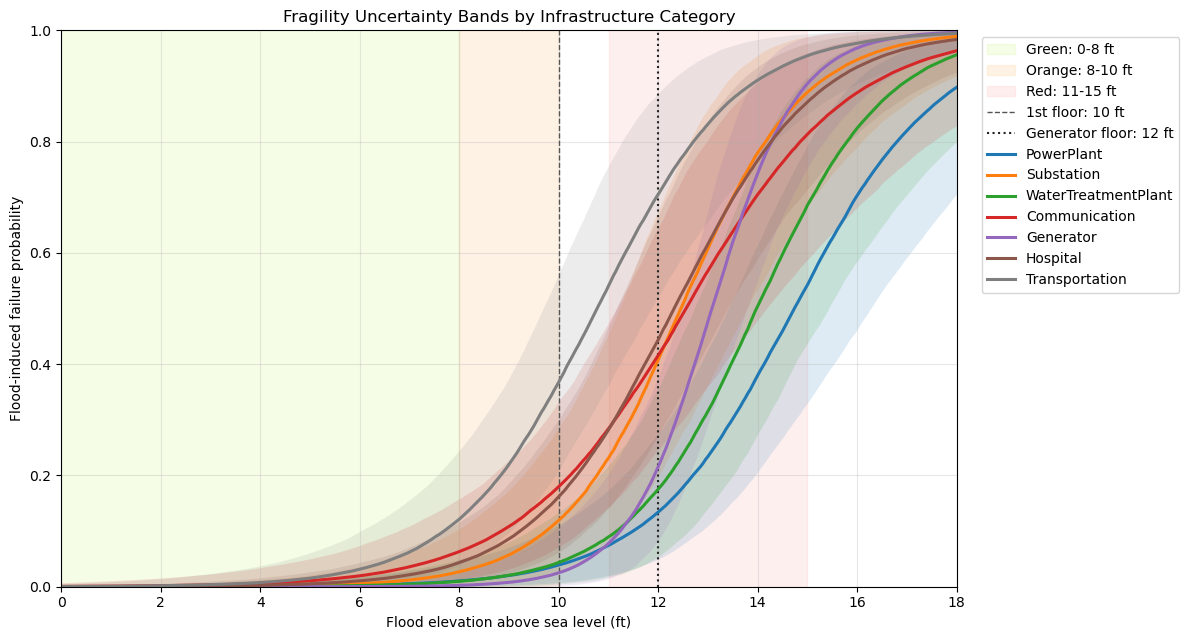

In [136]:
# ---------------------------------------------------------------------
# Plot category-level uncertainty bands
# ---------------------------------------------------------------------

category_order = [
    "PowerPlant",
    "Substation",
    "WaterTreatmentPlant",
    "Communication",
    "Generator",
    "Hospital",
    "Transportation",
]

category_colors = {
    "PowerPlant": "#1f77b4",
    "Substation": "#ff7f0e",
    "WaterTreatmentPlant": "#2ca02c",
    "Communication": "#d62728",
    "Generator": "#9467bd",
    "Hospital": "#8c564b",
    "Transportation": "#7f7f7f",
}

plt.figure(figsize=(12, 6.5))

# HealthPark scenario bands
plt.axvspan(0, 8, color="#d9f99d", alpha=0.25, label="Green: 0-8 ft")
plt.axvspan(8, 10, color="#fed7aa", alpha=0.30, label="Orange: 8-10 ft")
plt.axvspan(11, 15, color="#fecaca", alpha=0.30, label="Red: 11-15 ft")

# Reference elevations from the HealthPark note
plt.axvline(10, color="#555555", linestyle="--", linewidth=1, label="1st floor: 10 ft")
plt.axvline(12, color="#222222", linestyle=":", linewidth=1.5, label="Generator floor: 12 ft")

for category in category_order:
    df = (
        category_uncertainty_summary[
            category_uncertainty_summary["node_category"] == category
        ]
        .sort_values("storm_surge_ft")
    )

    x = df["storm_surge_ft"].to_numpy(dtype=float)
    p05 = df["p05"].to_numpy(dtype=float)
    p50 = df["p50"].to_numpy(dtype=float)
    p95 = df["p95"].to_numpy(dtype=float)

    plt.fill_between(
        x,
        p05,
        p95,
        color=category_colors[category],
        alpha=0.14,
        linewidth=0,
    )

    plt.plot(
        x,
        p50,
        color=category_colors[category],
        linewidth=2.2,
        label=category,
    )

plt.xlabel("Flood elevation above sea level (ft)")
plt.ylabel("Flood-induced failure probability")
plt.title("Fragility Uncertainty Bands by Infrastructure Category")
plt.ylim(0, 1)
plt.xlim(0, 18)
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Dependency relationships

In [ ]:
# ---------------------------------------------------------------------
# Dependency relationship settings
# ---------------------------------------------------------------------
# This cell does not add or modify routine probability rows.
# Missing routine probabilities are handled by your existing p_routine function.

GENERATOR_RUNTIME_DAYS = 6.3
q_buffered = 0.0  # generator works before expiration
q_expired = 1.0   # generator expires after 6.3 days

dependency_model = {
    # Sequential power chain
    "SUB_1_failed": {"type": "deterministic_or", "parents": ["PP_1_failed"]},
    "SUB_2_failed": {"type": "deterministic_or", "parents": ["SUB_1_failed"]},
    "SUB_3_failed": {"type": "deterministic_or", "parents": ["SUB_2_failed"]},
    "SUB_4_failed": {"type": "deterministic_or", "parents": ["SUB_3_failed"]},
    "SUB_5_failed": {"type": "deterministic_or", "parents": ["SUB_4_failed"]},

    # Activation node
    "Generator_activated": {
        "type": "activation",
        "parents": ["SUB_5_failed"],
    },

    # Electrical failure due to generator expiration
    "ElectricalDistribution_failed": {
        "type": "generator_runtime",
        "parents": ["Generator_activated"],
        "runtime_days": GENERATOR_RUNTIME_DAYS,
        "q_buffered": q_buffered,
        "q_expired": q_expired,
    },

    # Water dependency
    "WaterDistribution_failed": {
        "type": "noisy_or",
        "parents": ["WTP_1_failed", "ElectricalDistribution_failed"],
        "strengths": [1.00, 0.85],
    },

    # Communication redundancy
    "Communication_Tier1_failed": {
        "type": "redundant_all_failed",
        "parents": ["LEE_DARK_FIBER_failed", "LUMEN_MPLS_failed", "COMCAST_ENS_failed"],
    },
    "Communication_Tier2_failed": {
        "type": "redundant_all_failed",
        "parents": ["LUMEN_MPLS_failed", "COMCAST_ENS_failed"],
    },
    "Communication_Tier3_failed": {
        "type": "redundant_all_failed",
        "parents": ["LUMEN_MPLS_failed", "COMCAST_BUSINESS_failed", "TMOBILE_5G_failed"],
    },

    # Transportation / operations
    "Operations_capability_reduced": {
        "type": "deterministic_or",
        "parents": ["roads_bridges_closure"],
    },

    # Hospital tier dependencies
    "Tier1_failed": {
        "type": "noisy_or",
        "parents": [
            "ElectricalDistribution_failed",
            "WaterDistribution_failed",
            "Communication_Tier1_failed",
            "Operations_capability_reduced",
        ],
        "strengths": [0.95, 0.85, 0.70, 0.60],
    },
    "Tier2_failed": {
        "type": "noisy_or",
        "parents": [
            "ElectricalDistribution_failed",
            "WaterDistribution_failed",
            "Communication_Tier2_failed",
            "Operations_capability_reduced",
        ],
        "strengths": [0.90, 0.80, 0.65, 0.55],
    },
    "Tier3_failed": {
        "type": "noisy_or",
        "parents": [
            "ElectricalDistribution_failed",
            "WaterDistribution_failed",
            "Communication_Tier3_failed",
            "Operations_capability_reduced",
        ],
        "strengths": [0.85, 0.75, 0.60, 0.50],
    },
}


def noisy_or_from_states(parent_states, strengths):
    active_strengths = [
        strength
        for parent_state, strength in zip(parent_states, strengths)
        if parent_state == 1
    ]
    if not active_strengths:
        return 0.0
    return combine_independent_probabilities(*active_strengths)


def parent_caused_failure_probability(child, current_states, event_elapsed_days):
    spec = dependency_model.get(child)

    if spec is None:
        return 0.0

    parent_states = [current_states[parent] for parent in spec["parents"]]

    if spec["type"] == "activation":
        return 1.0 if parent_states[0] == 1 else 0.0

    if spec["type"] == "deterministic_or":
        return 1.0 if any(parent_states) else 0.0

    if spec["type"] == "redundant_all_failed":
        return 1.0 if all(parent_states) else 0.0

    if spec["type"] == "noisy_or":
        return noisy_or_from_states(parent_states, spec["strengths"])

    if spec["type"] == "generator_runtime":
        if parent_states[0] == 0:
            return 0.0

        if event_elapsed_days <= spec["runtime_days"]:
            return spec["q_buffered"]

        return spec["q_expired"]

    raise ValueError(f"Unknown dependency type for {child}: {spec['type']}")

## Temporal persistence

In [143]:
# ---------------------------------------------------------------------
# Temporal recovery settings
# ---------------------------------------------------------------------

RECOVERY_TREND_EPSILON_FT = 0.05

recovery_parameter_table = pd.DataFrame([
    {
        "node_category": "PowerPlant",
        "mean_recovery_hours_accessible": 48,
        "h_caution_ft": 10,
        "h_blocked_ft": 13,
    },
    {
        "node_category": "Substation",
        "mean_recovery_hours_accessible": 24,
        "h_caution_ft": 9,
        "h_blocked_ft": 12,
    },
    {
        "node_category": "WaterTreatmentPlant",
        "mean_recovery_hours_accessible": 48,
        "h_caution_ft": 10,
        "h_blocked_ft": 13,
    },
    {
        "node_category": "Communication",
        "mean_recovery_hours_accessible": 12,
        "h_caution_ft": 8,
        "h_blocked_ft": 12,
    },
    {
        "node_category": "Transportation",
        "mean_recovery_hours_accessible": 48,
        "h_caution_ft": 9,
        "h_blocked_ft": 12,
    },
    {
        "node_category": "Generator",
        "mean_recovery_hours_accessible": 12,
        "h_caution_ft": 12,
        "h_blocked_ft": 15,
    },
    {
        "node_category": "Hospital",
        "mean_recovery_hours_accessible": 16,
        "h_caution_ft": 10,
        "h_blocked_ft": 15,
    },
])

recovery_parameter_table["base_recovery_p_per_hour"] = (
    1.0 - np.exp(-1.0 / recovery_parameter_table["mean_recovery_hours_accessible"])
)

recovery_parameter_table

,node_category,mean_recovery_hours_accessible,h_caution_ft,h_blocked_ft,base_recovery_p_per_hour
0,PowerPlant,48,10,13,0.020618
1,Substation,24,9,12,0.040811
2,WaterTreatmentPlant,48,10,13,0.020618
3,Communication,12,8,12,0.079956
4,Transportation,48,9,12,0.020618
5,Generator,12,12,15,0.079956
6,Hospital,16,10,15,0.060587


In [144]:
# ---------------------------------------------------------------------
# Temporal recovery helper functions
# ---------------------------------------------------------------------

def recovery_access_factor(flood_elevation_ft, h_caution_ft, h_blocked_ft):
    if flood_elevation_ft >= h_blocked_ft:
        return 0.05
    if flood_elevation_ft >= h_caution_ft:
        return 0.25
    return 1.00


def recovery_trend_factor(current_flood_ft, previous_flood_ft, epsilon_ft=RECOVERY_TREND_EPSILON_FT):
    if previous_flood_ft is None:
        return 1.00

    delta_ft = current_flood_ft - previous_flood_ft

    if delta_ft > epsilon_ft:
        return 0.25
    if abs(delta_ft) <= epsilon_ft:
        return 0.60
    return 1.00


def recovery_probability(variable, current_flood_ft, previous_flood_ft=None):
    if variable == "Generator_activated":
        return 0.0

    if variable not in node_category_lookup:
        return 0.0

    node_category = node_category_lookup[variable]

    params = recovery_parameter_table[
        recovery_parameter_table["node_category"] == node_category
    ]

    if params.empty:
        return 0.0

    row = params.iloc[0]

    base_recovery_p = row["base_recovery_p_per_hour"]
    access_factor = recovery_access_factor(
        flood_elevation_ft=current_flood_ft,
        h_caution_ft=row["h_caution_ft"],
        h_blocked_ft=row["h_blocked_ft"],
    )
    trend_factor = recovery_trend_factor(
        current_flood_ft=current_flood_ft,
        previous_flood_ft=previous_flood_ft,
    )

    return float(base_recovery_p * access_factor * trend_factor)

In [145]:
# ---------------------------------------------------------------------
# Example: temporal persistence calculation for one simulated node state
# ---------------------------------------------------------------------

def sample_temporal_persistence(previous_state, recovery_p, rng):
    if previous_state == 0:
        return 0

    remains_failed = rng.random() < (1.0 - recovery_p)
    return int(remains_failed)

# Flood depth mapping

In [141]:
# ---------------------------------------------------------------------
# Read full USGS file and aggregate 15-min data to hourly maximum
# ---------------------------------------------------------------------

file_path = r"../../Data/Ian/FL - USGS-02291673.xls"
df_usgs = pd.read_excel(file_path)

df_usgs["time"] = pd.to_datetime(df_usgs["time"], utc=True)
df_usgs["time_local"] = df_usgs["time"].dt.tz_convert("America/New_York")

df_usgs = df_usgs.sort_values("time_local").reset_index(drop=True)

df_flood_hourly = (
    df_usgs
    .set_index("time_local")
    .resample("1h")
    .max(numeric_only=True)
    .dropna(subset=["value_meter"])
    .reset_index()
)

df_flood_hourly["time_step"] = np.arange(len(df_flood_hourly))
df_flood_hourly["event_elapsed_hours"] = (
    df_flood_hourly["time_local"] - df_flood_hourly["time_local"].iloc[0]
).dt.total_seconds() / 3600.0
df_flood_hourly["event_elapsed_days"] = df_flood_hourly["event_elapsed_hours"] / 24.0

df_flood_hourly["water_elevation_m"] = df_flood_hourly["value_meter"]
df_flood_hourly["water_elevation_ft"] = df_flood_hourly["water_elevation_m"] / FT_TO_M

DBN_HAZARD_COL = "water_elevation_ft"

display(df_flood_hourly)

print("Hourly rows:", len(df_flood_hourly))
print("Start:", df_flood_hourly["time_local"].iloc[0])
print("End:", df_flood_hourly["time_local"].iloc[-1])
print("Peak ft:", df_flood_hourly["water_elevation_ft"].max())

,time_local,x,y,parameter_code,statistic_id,value,value_meter,qualifier,time_step,event_elapsed_hours,event_elapsed_days,water_elevation_m,water_elevation_ft
0,2022-09-24 00:00:00-04:00,NaN,NaN,65,11,6.22,1.895856,NaN,0,0.0,0.000000,1.895856,6.22
1,2022-09-24 01:00:00-04:00,NaN,NaN,65,11,6.22,1.895856,NaN,1,1.0,0.041667,1.895856,6.22
2,2022-09-24 02:00:00-04:00,NaN,NaN,65,11,6.22,1.895856,NaN,2,2.0,0.083333,1.895856,6.22
3,2022-09-24 03:00:00-04:00,NaN,NaN,65,11,6.22,1.895856,NaN,3,3.0,0.125000,1.895856,6.22
4,2022-09-24 04:00:00-04:00,NaN,NaN,65,11,6.21,1.892808,NaN,4,4.0,0.166667,1.892808,6.21
...,...,...,...,...,...,...,...,...,...,...,...,...,...
355,2022-10-08 19:00:00-04:00,NaN,NaN,65,11,6.33,1.929384,NaN,355,355.0,14.791667,1.929384,6.33
356,2022-10-08 20:00:00-04:00,NaN,NaN,65,11,6.32,1.926336,NaN,356,356.0,14.833333,1.926336,6.32
357,2022-10-08 21:00:00-04:00,NaN,NaN,65,11,6.32,1.926336,NaN,357,357.0,14.875000,1.926336,6.32
358,2022-10-08 22:00:00-04:00,NaN,NaN,65,11,6.32,1.926336,NaN,358,358.0,14.916667,1.926336,6.32


Hourly rows: 360
Start: 2022-09-24 00:00:00-04:00
End: 2022-10-08 23:00:00-04:00
Peak ft: 10.659999658880011


In [156]:
df_flood_hourly["water_elevation_ft"].describe().round(2)

count    360.00
mean       6.72
std        0.78
min        5.96
25%        6.22
50%        6.56
75%        6.86
max       10.66
Name: water_elevation_ft, dtype: float64

In [142]:
# ---------------------------------------------------------------------
# 4. Build depth series for every node at every timestamp
# ---------------------------------------------------------------------

G_hosp = nx.DiGraph()
G_hosp.add_edges_from(
    dependency_edges[["parent", "child"]].itertuples(index=False, name=None)
)

if not nx.is_directed_acyclic_graph(G_hosp):
    raise ValueError("The established dependency network contains a cycle.")

dbn_node_order = list(nx.topological_sort(G_hosp))

def build_depth_series_same_for_all_nodes(G, df_flood, depth_col=DBN_HAZARD_COL):
    depths_series = []

    for _, row in df_flood.iterrows():
        depths_series.append({
            "time_step": int(row["time_step"]),
            "time_local": row["time_local"],
            "event_elapsed_hours": float(row["event_elapsed_hours"]),
            "event_elapsed_days": float(row["event_elapsed_days"]),
            "depth_by_node": {
                node: float(row[depth_col])
                for node in G.nodes()
            },
        })

    return depths_series

depths_series = build_depth_series_same_for_all_nodes(
    G_hosp,
    df_flood_hourly,
    depth_col=DBN_HAZARD_COL,
)

print("Number of DBN hourly timestamps:", len(depths_series))
print("Example first timestamp:", depths_series[0])

Number of DBN hourly timestamps: 360
Example first timestamp: {'time_step': 0, 'time_local': Timestamp('2022-09-24 00:00:00-0400', tz='America/New_York'), 'event_elapsed_hours': 0.0, 'event_elapsed_days': 0.0, 'depth_by_node': {'PP_1_failed': 6.219999800960006, 'SUB_1_failed': 6.219999800960006, 'SUB_2_failed': 6.219999800960006, 'SUB_3_failed': 6.219999800960006, 'SUB_4_failed': 6.219999800960006, 'SUB_5_failed': 6.219999800960006, 'Generator_activated': 6.219999800960006, 'ElectricalDistribution_failed': 6.219999800960006, 'WTP_1_failed': 6.219999800960006, 'WaterDistribution_failed': 6.219999800960006, 'LEE_DARK_FIBER_failed': 6.219999800960006, 'Communication_Tier1_failed': 6.219999800960006, 'LUMEN_MPLS_failed': 6.219999800960006, 'COMCAST_ENS_failed': 6.219999800960006, 'Communication_Tier2_failed': 6.219999800960006, 'Communication_Tier3_failed': 6.219999800960006, 'COMCAST_BUSINESS_failed': 6.219999800960006, 'TMOBILE_5G_failed': 6.219999800960006, 'roads_bridges_closure': 6.21

# DBN inference

In [146]:
# ---------------------------------------------------------------------
# DBN inference setup checks
# ---------------------------------------------------------------------

if not nx.is_directed_acyclic_graph(G_hosp):
    raise ValueError("G_hosp must be a directed acyclic graph for within-slice DBN sampling.")

dbn_node_order = list(nx.topological_sort(G_hosp))

missing_dependency_specs = [
    node for node in dbn_node_order
    if G_hosp.in_degree(node) > 0 and node not in dependency_model
]
if missing_dependency_specs:
    raise ValueError(f"Missing dependency_model specs for: {missing_dependency_specs}")

print("DBN nodes:", len(dbn_node_order))
print("DBN time steps:", len(depths_series))
print("Recovery categories:", recovery_parameter_table["node_category"].tolist())

DBN nodes: 23
DBN time steps: 360
Recovery categories: ['PowerPlant', 'Substation', 'WaterTreatmentPlant', 'Communication', 'Transportation', 'Generator', 'Hospital']


In [147]:
# ---------------------------------------------------------------------
# DBN Monte Carlo helper functions
# ---------------------------------------------------------------------

def direct_flood_probability(variable, flood_elevation_ft):
    if variable == "Generator_activated":
        return 0.0

    if variable not in node_category_lookup:
        return 0.0

    return p_flood_failure_by_category(
        node_category_lookup[variable],
        flood_elevation_ft,
    )


def sample_independent_event(probability, rng):
    probability = min(max(float(probability), 0.0), 1.0)
    return int(rng.random() < probability)


def sample_parent_cause_events(child, current_states, event_elapsed_days, rng):
    """
    Returns a dict of parent-caused events for this child.
    Keys are cause labels and values are 0/1 sampled events.
    """
    spec = dependency_model.get(child)

    if spec is None:
        return {}

    parent_states = {
        parent: current_states[parent]
        for parent in spec["parents"]
    }

    if spec["type"] == "activation":
        parent = spec["parents"][0]
        return {
            parent: int(parent_states[parent] == 1)
        }

    if spec["type"] == "deterministic_or":
        return {
            parent: int(state == 1)
            for parent, state in parent_states.items()
        }

    if spec["type"] == "redundant_all_failed":
        all_failed = int(all(state == 1 for state in parent_states.values()))
        return {
            "redundant_provider_failures": all_failed
        }

    if spec["type"] == "noisy_or":
        events = {}
        for parent, strength in zip(spec["parents"], spec["strengths"]):
            if parent_states[parent] == 1:
                events[parent] = sample_independent_event(strength, rng)
            else:
                events[parent] = 0
        return events

    if spec["type"] == "generator_runtime":
        parent = spec["parents"][0]

        if parent_states[parent] == 0:
            return {"generator_runtime_expired": 0}

        if event_elapsed_days <= spec["runtime_days"]:
            q_generator_failure = spec["q_buffered"]
        else:
            q_generator_failure = spec["q_expired"]

        return {
            "generator_runtime_expired": sample_independent_event(q_generator_failure, rng)
        }

    raise ValueError(f"Unknown dependency type for {child}: {spec['type']}")


def sample_temporal_event(variable, previous_state, current_flood_ft, previous_flood_ft, rng):
    """
    Samples whether previous failure persists into the current timestamp.

    Nodes without category mapping are treated as instantaneous service/logic nodes:
    they do not receive temporal persistence unless explicitly mapped.
    """
    if previous_state == 0:
        return 0

    if variable == "Generator_activated":
        return 0

    if variable not in node_category_lookup:
        return 0

    recovery_p = recovery_probability(
        variable=variable,
        current_flood_ft=current_flood_ft,
        previous_flood_ft=previous_flood_ft,
    )

    return int(rng.random() >= recovery_p)


def allocate_failure_cause_shares(active_causes):
    """
    Fractionally attributes one failed node-state across all active causes.
    If a failure has two active causes, each receives 0.5.
    """
    active_causes = [cause for cause, active in active_causes.items() if active == 1]

    if not active_causes:
        return {}

    share = 1.0 / len(active_causes)
    return {cause: share for cause in active_causes}

In [ ]:
# ---------------------------------------------------------------------
# DBN Monte Carlo simulation
# ---------------------------------------------------------------------

def run_dbn_monte_carlo(depths_series, n_samples=10000, seed=42):
    rng = np.random.default_rng(seed)

    state_records = []
    cause_records = []

    tier_nodes = ["Tier1_failed", "Tier2_failed", "Tier3_failed"]

    for sample_id in range(n_samples):
        previous_states = {node: 0 for node in dbn_node_order}
        previous_depth_by_node = None

        if sample_id % 500 == 0:
            print(f"Running DBN Monte Carlo sample {sample_id} of {n_samples}...")

        for step in depths_series:
            time_step = step["time_step"]
            time_local = step["time_local"]
            event_elapsed_hours = step["event_elapsed_hours"]
            event_elapsed_days = step["event_elapsed_days"]
            depth_by_node = step["depth_by_node"]

            current_states = {}

            for node in dbn_node_order:
                current_flood_ft = depth_by_node[node]
                previous_flood_ft = None
                if previous_depth_by_node is not None:
                    previous_flood_ft = previous_depth_by_node[node]

                if node == "Generator_activated":
                    parent_events = sample_parent_cause_events(
                        child=node,
                        current_states=current_states,
                        event_elapsed_days=event_elapsed_days,
                        rng=rng,
                    )
                    state = int(any(parent_events.values()))

                    routine_event = 0
                    flood_event = 0
                    temporal_event = 0

                else:
                    routine_event = sample_independent_event(p_routine(node), rng)
                    flood_event = sample_independent_event(
                        direct_flood_probability(node, current_flood_ft),
                        rng,
                    )
                    temporal_event = sample_temporal_event(
                        variable=node,
                        previous_state=previous_states[node],
                        current_flood_ft=current_flood_ft,
                        previous_flood_ft=previous_flood_ft,
                        rng=rng,
                    )
                    parent_events = sample_parent_cause_events(
                        child=node,
                        current_states=current_states,
                        event_elapsed_days=event_elapsed_days,
                        rng=rng,
                    )

                    state = int(
                        routine_event == 1
                        or flood_event == 1
                        or temporal_event == 1
                        or any(parent_events.values())
                    )

                current_states[node] = state

                state_records.append({
                    "sample_id": sample_id,
                    "time_step": time_step,
                    "time_local": time_local,
                    "event_elapsed_hours": event_elapsed_hours,
                    "event_elapsed_days": event_elapsed_days,
                    "variable": node,
                    "flood_elevation_ft": current_flood_ft,
                    "state": state,
                })

                if node in tier_nodes and state == 1:
                    active_causes = {
                        "routine": routine_event,
                        "direct_flood": flood_event,
                        "temporal_persistence": temporal_event,
                    }

                    # Rename parent causes into readable tier-level cause categories.
                    for cause, active in parent_events.items():
                        if cause == "ElectricalDistribution_failed":
                            active_causes["electrical_distribution"] = active
                        elif cause == "WaterDistribution_failed":
                            active_causes["water_distribution"] = active
                        elif cause.startswith("Communication_Tier"):
                            active_causes["communication"] = active
                        elif cause == "Operations_capability_reduced":
                            active_causes["operations_transportation"] = active
                        else:
                            active_causes[cause] = active

                    cause_shares = allocate_failure_cause_shares(active_causes)

                    for cause, share in cause_shares.items():
                        cause_records.append({
                            "sample_id": sample_id,
                            "time_step": time_step,
                            "time_local": time_local,
                            "event_elapsed_hours": event_elapsed_hours,
                            "event_elapsed_days": event_elapsed_days,
                            "tier": node,
                            "cause": cause,
                            "cause_share": share,
                        })

            previous_states = current_states
            previous_depth_by_node = depth_by_node

    dbn_state_samples = pd.DataFrame(state_records)
    dbn_tier_cause_samples = pd.DataFrame(cause_records)

    return dbn_state_samples, dbn_tier_cause_samples


dbn_state_samples, dbn_tier_cause_samples = run_dbn_monte_carlo(
    depths_series=depths_series,
    n_samples=10000,
    seed=42,
)

display(dbn_state_samples.head())
display(dbn_tier_cause_samples.head())

Running DBN Monte Carlo sample 0 of 10000...
Running DBN Monte Carlo sample 500 of 10000...
Running DBN Monte Carlo sample 1000 of 10000...
Running DBN Monte Carlo sample 1500 of 10000...
Running DBN Monte Carlo sample 2000 of 10000...
Running DBN Monte Carlo sample 2500 of 10000...
Running DBN Monte Carlo sample 3000 of 10000...
Running DBN Monte Carlo sample 3500 of 10000...
Running DBN Monte Carlo sample 4000 of 10000...
Running DBN Monte Carlo sample 4500 of 10000...
Running DBN Monte Carlo sample 5000 of 10000...
Running DBN Monte Carlo sample 5500 of 10000...
Running DBN Monte Carlo sample 6000 of 10000...
Running DBN Monte Carlo sample 6500 of 10000...
Running DBN Monte Carlo sample 7000 of 10000...
Running DBN Monte Carlo sample 7500 of 10000...
Running DBN Monte Carlo sample 8000 of 10000...
Running DBN Monte Carlo sample 8500 of 10000...
Running DBN Monte Carlo sample 9000 of 10000...
Running DBN Monte Carlo sample 9500 of 10000...


,sample_id,time_step,time_local,event_elapsed_hours,event_elapsed_days,variable,flood_elevation_ft,state
0,0,0,2022-09-24 00:00:00-04:00,0.0,0.0,PP_1_failed,6.22,0
1,0,0,2022-09-24 00:00:00-04:00,0.0,0.0,WTP_1_failed,6.22,0
2,0,0,2022-09-24 00:00:00-04:00,0.0,0.0,LEE_DARK_FIBER_failed,6.22,0
3,0,0,2022-09-24 00:00:00-04:00,0.0,0.0,LUMEN_MPLS_failed,6.22,0
4,0,0,2022-09-24 00:00:00-04:00,0.0,0.0,COMCAST_ENS_failed,6.22,0


,sample_id,time_step,time_local,event_elapsed_hours,event_elapsed_days,tier,cause,cause_share
0,0,3,2022-09-24 03:00:00-04:00,3.0,0.125000,Tier1_failed,operations_transportation,1.0
1,0,4,2022-09-24 04:00:00-04:00,4.0,0.166667,Tier1_failed,temporal_persistence,0.5
2,0,4,2022-09-24 04:00:00-04:00,4.0,0.166667,Tier1_failed,operations_transportation,0.5
3,0,4,2022-09-24 04:00:00-04:00,4.0,0.166667,Tier3_failed,operations_transportation,1.0
4,0,5,2022-09-24 05:00:00-04:00,5.0,0.208333,Tier1_failed,temporal_persistence,1.0


In [152]:
# ---------------------------------------------------------------------
# Summarize DBN failure probabilities
# ---------------------------------------------------------------------

dbn_probability_summary = (
    dbn_state_samples
    .groupby(["time_step", "time_local", "event_elapsed_hours", "event_elapsed_days", "variable"], as_index=False)
    .agg(
        p_failed_or_activated=("state", "mean"),
        flood_elevation_ft=("flood_elevation_ft", "mean"),
    )
)

dbn_probability_wide = dbn_probability_summary.pivot(
    index=["time_step", "time_local", "event_elapsed_hours", "event_elapsed_days", "flood_elevation_ft"],
    columns="variable",
    values="p_failed_or_activated",
).reset_index()

tier_probability_summary = dbn_probability_summary[
    dbn_probability_summary["variable"].isin(["Tier1_failed", "Tier2_failed", "Tier3_failed"])
].copy()

display(dbn_probability_summary.head())
display(dbn_probability_wide.head())
display(tier_probability_summary.head())

,time_step,time_local,event_elapsed_hours,event_elapsed_days,variable,p_failed_or_activated,flood_elevation_ft
0,0,2022-09-24 00:00:00-04:00,0.0,0.0,COMCAST_BUSINESS_failed,0.0186,6.22
1,0,2022-09-24 00:00:00-04:00,0.0,0.0,COMCAST_ENS_failed,0.0212,6.22
2,0,2022-09-24 00:00:00-04:00,0.0,0.0,Communication_Tier1_failed,0.0000,6.22
3,0,2022-09-24 00:00:00-04:00,0.0,0.0,Communication_Tier2_failed,0.0002,6.22
4,0,2022-09-24 00:00:00-04:00,0.0,0.0,Communication_Tier3_failed,0.0000,6.22


variable,time_step,time_local,event_elapsed_hours,event_elapsed_days,flood_elevation_ft,COMCAST_BUSINESS_failed,COMCAST_ENS_failed,Communication_Tier1_failed,Communication_Tier2_failed,Communication_Tier3_failed,ElectricalDistribution_failed,Generator_activated,LEE_DARK_FIBER_failed,LUMEN_MPLS_failed,Operations_capability_reduced,PP_1_failed,SUB_1_failed,SUB_2_failed,SUB_3_failed,SUB_4_failed,SUB_5_failed,TMOBILE_5G_failed,Tier1_failed,Tier2_failed,Tier3_failed,WTP_1_failed,WaterDistribution_failed,roads_bridges_closure
0,0,2022-09-24 00:00:00-04:00,0.0,0.000000,6.22,0.0186,0.0212,0.0000,0.0002,0.0000,0.0002,0.0354,0.0177,0.0195,0.0278,0.0049,0.0115,0.0173,0.0227,0.0291,0.0354,0.0182,0.0326,0.0298,0.0312,0.0041,0.0041,0.0278
1,1,2022-09-24 01:00:00-04:00,1.0,0.041667,6.22,0.0396,0.0391,0.0000,0.0012,0.0000,0.0004,0.0713,0.0350,0.0374,0.0537,0.0111,0.0235,0.0354,0.0470,0.0591,0.0713,0.0364,0.0748,0.0681,0.0706,0.0090,0.0094,0.0537
2,2,2022-09-24 02:00:00-04:00,2.0,0.083333,6.22,0.0555,0.0555,0.0000,0.0026,0.0003,0.0006,0.1051,0.0517,0.0545,0.0820,0.0145,0.0344,0.0522,0.0700,0.0874,0.1051,0.0543,0.1163,0.1097,0.1101,0.0142,0.0147,0.0820
3,3,2022-09-24 03:00:00-04:00,3.0,0.125000,6.22,0.0708,0.0726,0.0002,0.0046,0.0002,0.0008,0.1412,0.0678,0.0694,0.1033,0.0196,0.0456,0.0694,0.0951,0.1185,0.1412,0.0714,0.1508,0.1485,0.1461,0.0172,0.0180,0.1033
4,4,2022-09-24 04:00:00-04:00,4.0,0.166667,6.21,0.0879,0.0885,0.0002,0.0079,0.0005,0.0011,0.1751,0.0826,0.0830,0.1263,0.0241,0.0545,0.0865,0.1173,0.1478,0.1751,0.0830,0.1841,0.1863,0.1784,0.0218,0.0226,0.1263


,time_step,time_local,event_elapsed_hours,event_elapsed_days,variable,p_failed_or_activated,flood_elevation_ft
17,0,2022-09-24 00:00:00-04:00,0.0,0.000000,Tier1_failed,0.0326,6.22
18,0,2022-09-24 00:00:00-04:00,0.0,0.000000,Tier2_failed,0.0298,6.22
19,0,2022-09-24 00:00:00-04:00,0.0,0.000000,Tier3_failed,0.0312,6.22
40,1,2022-09-24 01:00:00-04:00,1.0,0.041667,Tier1_failed,0.0748,6.22
41,1,2022-09-24 01:00:00-04:00,1.0,0.041667,Tier2_failed,0.0681,6.22


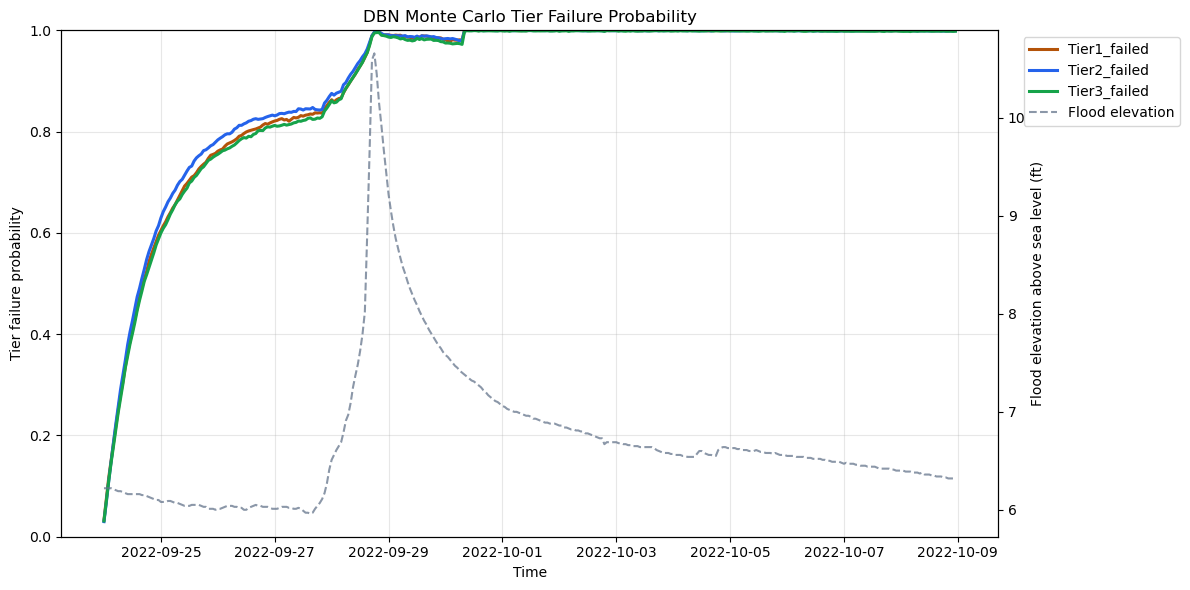

In [153]:
# ---------------------------------------------------------------------
# Plot Tier 1, Tier 2, and Tier 3 failure probabilities
# ---------------------------------------------------------------------

tier_plot_colors = {
    "Tier1_failed": "#b45309",
    "Tier2_failed": "#2563eb",
    "Tier3_failed": "#16a34a",
}

plt.figure(figsize=(12, 6))

ax1 = plt.gca()

for tier, color in tier_plot_colors.items():
    df_tier = tier_probability_summary[
        tier_probability_summary["variable"] == tier
    ].sort_values("time_local")

    ax1.plot(
        df_tier["time_local"],
        df_tier["p_failed_or_activated"],
        linewidth=2.2,
        color=color,
        label=tier,
    )

ax1.set_xlabel("Time")
ax1.set_ylabel("Tier failure probability")
ax1.set_ylim(0, 1)
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
flood_plot_df = dbn_probability_wide.sort_values("time_local")
ax2.plot(
    flood_plot_df["time_local"],
    flood_plot_df["flood_elevation_ft"],
    color="#64748b",
    linestyle="--",
    linewidth=1.5,
    alpha=0.75,
    label="Flood elevation",
)
ax2.set_ylabel("Flood elevation above sea level (ft)")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

plt.title("DBN Monte Carlo Tier Failure Probability")
plt.tight_layout()
plt.show()

In [154]:
# ---------------------------------------------------------------------
# Summarize failure-cause composition for Tier 1, Tier 2, and Tier 3
# ---------------------------------------------------------------------

if dbn_tier_cause_samples.empty:
    tier_cause_time_summary = pd.DataFrame()
    tier_cause_overall_summary = pd.DataFrame()
else:
    tier_cause_time_summary = (
        dbn_tier_cause_samples
        .groupby(["time_step", "time_local", "event_elapsed_hours", "event_elapsed_days", "tier", "cause"], as_index=False)
        .agg(cause_share_sum=("cause_share", "sum"))
    )

    # Normalize cause shares by total failed samples per tier/time.
    failed_counts = (
        dbn_state_samples[
            dbn_state_samples["variable"].isin(["Tier1_failed", "Tier2_failed", "Tier3_failed"])
        ]
        .groupby(["time_step", "time_local", "event_elapsed_hours", "event_elapsed_days", "variable"], as_index=False)
        .agg(failed_samples=("state", "sum"))
        .rename(columns={"variable": "tier"})
    )

    tier_cause_time_summary = tier_cause_time_summary.merge(
        failed_counts,
        on=["time_step", "time_local", "event_elapsed_hours", "event_elapsed_days", "tier"],
        how="left",
    )

    tier_cause_time_summary["cause_fraction_given_failure"] = (
        tier_cause_time_summary["cause_share_sum"] / tier_cause_time_summary["failed_samples"]
    )

    tier_cause_time_summary["cause_probability_contribution"] = (
        tier_cause_time_summary["cause_share_sum"] / dbn_state_samples["sample_id"].nunique()
    )

    tier_cause_overall_summary = (
        dbn_tier_cause_samples
        .groupby(["tier", "cause"], as_index=False)
        .agg(cause_share_sum=("cause_share", "sum"))
    )

    tier_failed_overall = (
        dbn_state_samples[
            dbn_state_samples["variable"].isin(["Tier1_failed", "Tier2_failed", "Tier3_failed"])
        ]
        .groupby("variable", as_index=False)
        .agg(failed_state_count=("state", "sum"))
        .rename(columns={"variable": "tier"})
    )

    tier_cause_overall_summary = tier_cause_overall_summary.merge(
        tier_failed_overall,
        on="tier",
        how="left",
    )

    tier_cause_overall_summary["cause_fraction_given_failure"] = (
        tier_cause_overall_summary["cause_share_sum"]
        / tier_cause_overall_summary["failed_state_count"]
    )

display(tier_cause_time_summary.head())
display(tier_cause_overall_summary)

,time_step,time_local,event_elapsed_hours,event_elapsed_days,tier,cause,cause_share_sum,failed_samples,cause_fraction_given_failure,cause_probability_contribution
0,0,2022-09-24 00:00:00-04:00,0.0,0.0,Tier1_failed,direct_flood,128.5,326,0.394172,0.01285
1,0,2022-09-24 00:00:00-04:00,0.0,0.0,Tier1_failed,electrical_distribution,1.0,326,0.003067,0.00010
2,0,2022-09-24 00:00:00-04:00,0.0,0.0,Tier1_failed,operations_transportation,161.0,326,0.493865,0.01610
3,0,2022-09-24 00:00:00-04:00,0.0,0.0,Tier1_failed,water_distribution,35.5,326,0.108896,0.00355
4,0,2022-09-24 00:00:00-04:00,0.0,0.0,Tier2_failed,communication,2.0,298,0.006711,0.00020


,tier,cause,cause_share_sum,failed_state_count,cause_fraction_given_failure
0,Tier1_failed,communication,6.183000e+04,3262456,0.018952
1,Tier1_failed,direct_flood,3.103567e+04,3262456,0.009513
2,Tier1_failed,electrical_distribution,6.550793e+05,3262456,0.200793
3,Tier1_failed,operations_transportation,5.300439e+05,3262456,0.162468
4,Tier1_failed,temporal_persistence,1.378176e+06,3262456,0.422435
5,Tier1_failed,water_distribution,6.062906e+05,3262456,0.185839
6,Tier2_failed,communication,1.182588e+05,3280405,0.036050
7,Tier2_failed,direct_flood,3.147982e+04,3280405,0.009596
8,Tier2_failed,electrical_distribution,6.316749e+05,3280405,0.192560
9,Tier2_failed,operations_transportation,4.890188e+05,3280405,0.149073


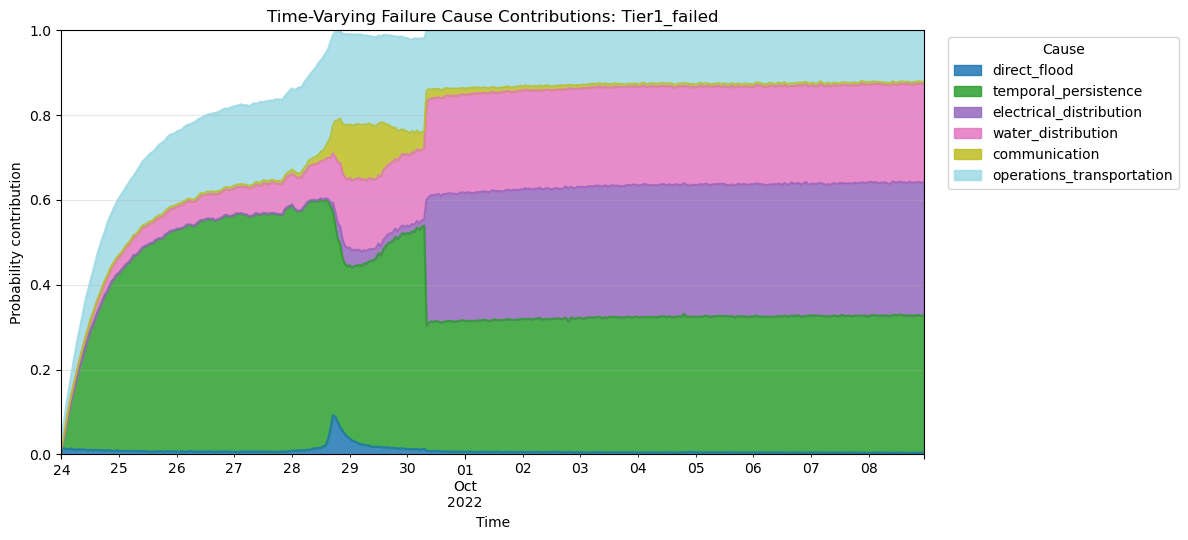

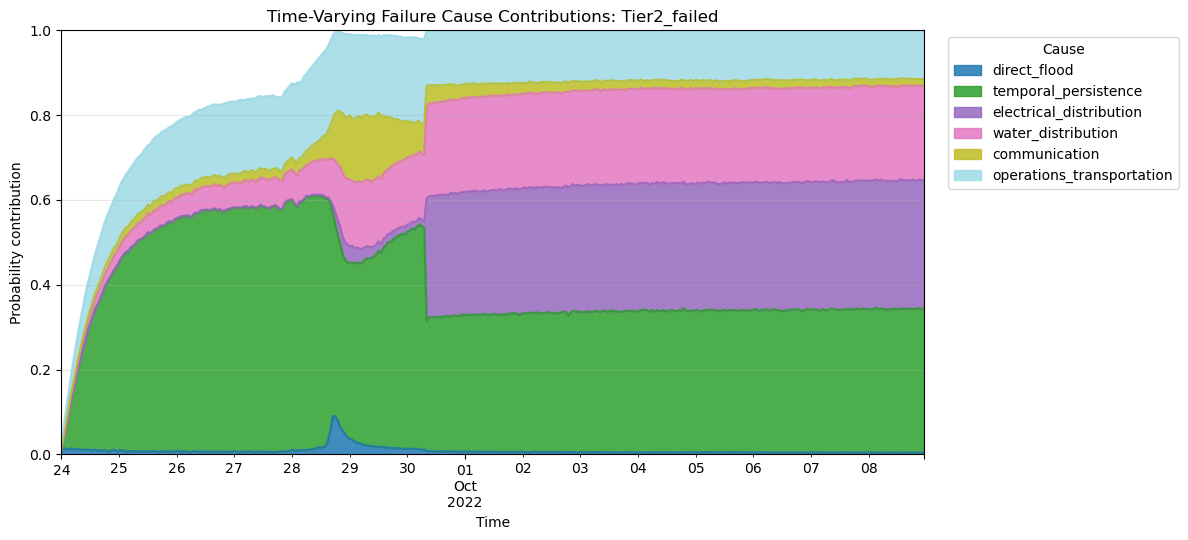

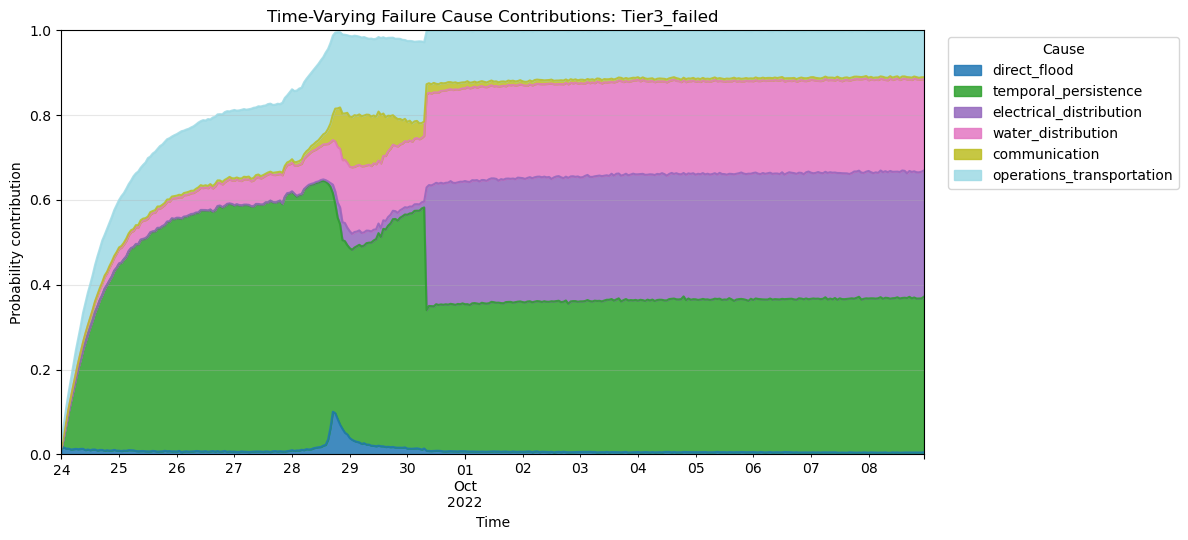

In [155]:
# ---------------------------------------------------------------------
# Plot time-varying cause composition for each tier
# ---------------------------------------------------------------------

if not tier_cause_time_summary.empty:
    for tier in ["Tier1_failed", "Tier2_failed", "Tier3_failed"]:
        df_tier_causes = tier_cause_time_summary[
            tier_cause_time_summary["tier"] == tier
        ].copy()

        cause_time_pivot = (
            df_tier_causes
            .pivot_table(
                index="time_local",
                columns="cause",
                values="cause_probability_contribution",
                aggfunc="sum",
            )
            .fillna(0.0)
            .sort_index()
        )

        ordered_columns = [
            cause for cause in [
                "direct_flood",
                "temporal_persistence",
                "electrical_distribution",
                "water_distribution",
                "communication",
                "operations_transportation",
                "routine",
            ]
            if cause in cause_time_pivot.columns
        ]
        remaining_columns = [
            cause for cause in cause_time_pivot.columns
            if cause not in ordered_columns
        ]

        cause_time_pivot = cause_time_pivot[ordered_columns + remaining_columns]

        ax = cause_time_pivot.plot(
            kind="area",
            stacked=True,
            figsize=(12, 5.5),
            alpha=0.85,
            colormap="tab20",
        )

        ax.set_xlabel("Time")
        ax.set_ylabel("Probability contribution")
        ax.set_ylim(0, 1)
        ax.set_title(f"Time-Varying Failure Cause Contributions: {tier}")
        ax.grid(axis="y", alpha=0.3)
        plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", title="Cause")
        plt.tight_layout()
        plt.show()

## Inference under uncertainty

https://www.sciencedirect.com/science/article/pii/S095183200200056X#SEC8

Epistemic uncertainty analysis is an essential feature of any model application subject to ‘state of knowledge’ uncertainties. Such analysis is usually carried out on the basis of a Monte Carlo simulation sampling the epistemic variables and performing the corresponding model runs.

In situations, however, where aleatory uncertainties are also present in the model, an adequate treatment of both types of uncertainties would require a two-stage nested Monte Carlo simulation, i.e. sampling the epistemic variables (‘outer loop’) and nested sampling of the aleatory variables (‘inner loop’). It is clear that for complex and long running codes the computational effort to perform all the resulting model runs may be prohibitive.

### Our case

- Epistemic outer-loop variables:
    - fragility curve parameters
    - dependency strengths
    - recovery-time parameters
    - generator runtime assumption

- Aleatory inner-loop variables:
    - whether each node fails at each timestamp
    - whether recovery occurs
    - whether noisy-OR parent causes trigger failure

- Scenario: a structured assumption set
- Outer loop: sample uncertain parameters
- Inner loop: run DBN state simulation under that sampled parameter set

### Uncertainty groups & scenarios

1. Fragility uncertainty
   - x_low_ft, p_low, x_high_ft, p_high by category

2. Dependency strength uncertainty
   - WaterDistribution_failed:
       - WTP_1_failed strength
       - ElectricalDistribution_failed strength

   - Tier1_failed:
       - electrical, water, communication, operations strengths
   - Tier2_failed:
       - electrical, water, communication, operations strengths
   - Tier3_failed:
       - electrical, water, communication, operations strengths

3. Recovery uncertainty
    - mean_recovery_hours_accessible by category
    - h_caution_ft
    - h_blocked_ft

4. Generator runtime uncertainty
   - runtime around 6.3 days

We do not know the exact parameter values, but instead of assigning one broad undifferentiated uncertainty range, we evaluate structured vulnerability scenarios and propagate residual parameter uncertainty within each scenario.

| Scenario | Fragility | Dependency | Recovery | Interpretation |
|---|---|---|---|---|
| Optimistic resilience | Lower fragility | Weaker dependency | Faster recovery | Assets are protected, redundancy works well |
| Baseline | Current settings | Current settings | Current settings | Central model |
| High vulnerability | Higher fragility | Stronger dependency | Slower recovery | Systems are more exposed and tightly coupled |
| High fragility only | Higher fragility | Baseline dependency | Baseline recovery | Tests sensitivity to flood damage curves |
| High dependency only | Baseline fragility | Stronger dependency | Baseline recovery | Tests cascading dependency assumptions |
| Slow recovery only | Baseline fragility | Baseline dependency | Slower recovery | Tests persistence/recovery assumptions |

Workflow:

1. Define scenario families.
2. For each scenario:
      a. Sample epistemic parameters inside that scenario’s narrowed ranges.
      b. For each sampled parameter set:
             run DBN Monte Carlo trajectories.
      c. Summarize Tier 1/2/3 failure probability.
3. Compare scenarios:
      - median curve
      - 5-95% uncertainty band
      - peak failure probability
      - cause composition

Implication:
- Decide when move patients